# GeoCareTool — Thimphu, Bhutan

End-to-end demonstration of the GeoCareTool modules on Thimphu (the capital of Bhutan):

1. **Web scraping** — Google Places API around Thimphu to inventory care facilities.
2. ~~Data cleaning~~ *(skipped)*
3. ~~Extra downloads~~ *(skipped)*
4. **Accessibility** — walking isochrones + synthetic GTFS + travel-time matrix.
5. **Care deserts** — combine demand and accessibility into desert indicators.

> The notebook is **not executed**. Replace the placeholder paths and your Google API key before running.

## 0 · Setup

In [2]:
import os
from pathlib import Path
from datetime import datetime

import pandas as pd
import geopandas as gpd
from dotenv import load_dotenv

load_dotenv()   # reads a local .env file if present

# Project paths — adjust to your local layout
ROOT = Path("./thimphu_outputs")
(ROOT / "scraping").mkdir(parents=True, exist_ok=True)
(ROOT / "accessibility").mkdir(parents=True, exist_ok=True)
(ROOT / "care_deserts").mkdir(parents=True, exist_ok=True)

# Thimphu bounding box (approx., WGS84)
THIMPHU_BBOX = {
    "min_lat": 27.40,
    "max_lat": 27.55,
    "min_lng": 89.58,
    "max_lng": 89.72,
}
GRID_STEP_M = 1500   # ~1.5 km grid spacing
GEO_CRS = "EPSG:4326"
METRIC_CRS = "EPSG:32646"   # UTM zone 46N — covers Bhutan

## 1 · Web scraping — Google Places (care facilities in Thimphu)

Generate a regular grid of search centers across the bounding box, then query the Google Places `nearbysearch` endpoint for each keyword of interest. Results from all grid points are concatenated and de-duplicated.

Grid points to query: 120


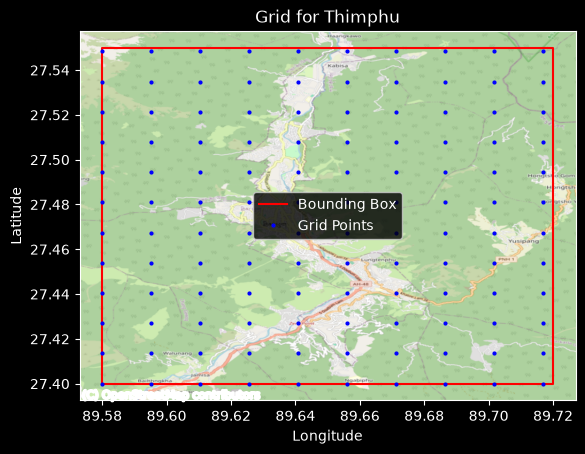

In [3]:
from GeoCareTool.GPlaces_Scraping.scraper import (
    generate_grid,
    plot_grid_with_basemap,
    fetch_places,
    load_and_concatenate_files,
)

GOOGLE_API_KEY = os.environ["GOOGLE_MAPS_DEMO_API_KEY"]   # set in .env or shell: export GOOGLE_API_KEY=...

grid = generate_grid(
    THIMPHU_BBOX["min_lat"], THIMPHU_BBOX["max_lat"],
    THIMPHU_BBOX["min_lng"], THIMPHU_BBOX["max_lng"],
    step=GRID_STEP_M,
)
print(f"Grid points to query: {len(grid)}")

# Optional: visualize the grid over a basemap
plot_grid_with_basemap(
    "Thimphu", grid,
    bounding_box=(
        THIMPHU_BBOX["min_lat"], THIMPHU_BBOX["max_lat"],
        THIMPHU_BBOX["min_lng"], THIMPHU_BBOX["max_lng"],
    ),
)

In [ ]:
# Care-related keywords. Extend / translate as needed.
# IMPORTANT NOTE ON PRICING: Google Places API charges per request, so be mindful of the number of grid points and keywords. DO NOT run this cell without checking your API usage limits and costs.
KEYWORDS = {
    "childcare":       ["daycare", "creche", "early childhood center", "kindergarten"],
    "elderly_care":    ["elderly care", "old age home", "senior care"],
    "disability_care": ["disability center", "special needs school", "rehabilitation center"],
    "health":          ["hospital", "clinic", "basic health unit"],
}

scraped = {}
for category, kw_list in KEYWORDS.items():
    dfs = []
    for kw in kw_list:
        for lat, lng in grid:
            df = fetch_places(lat, lng, keyword=kw, key=GOOGLE_API_KEY, step_size=GRID_STEP_M)
            if not df.empty:
                df["keyword"] = kw
                df["category"] = category
                dfs.append(df)
    if dfs:
        out = pd.concat(dfs, ignore_index=True).drop_duplicates("place_id")
        out.to_pickle(ROOT / "scraping" / f"{category}_thimphu.pkl")
        scraped[category] = out
        print(f"{category}: {len(out):,} unique places")

In [ ]:
# Consolidate all categories into one GeoDataFrame of supply points
all_places = load_and_concatenate_files(str(ROOT / "scraping" / "*_thimphu.pkl"))
facilities = gpd.GeoDataFrame(
    all_places,
    geometry=gpd.points_from_xy(all_places["lng"], all_places["lat"]),
    crs=GEO_CRS,
)
facilities.to_file(ROOT / "scraping" / "facilities_thimphu.gpkg", driver="GPKG")
print(f"Total facilities (all categories): {len(facilities):,}")
facilities.head()

## 2 · ~~Data cleaning~~  ·  3 · ~~Extra downloads~~

Skipped per instructions.

## 4 · Accessibility

### 4.1 · Walking isochrones (20 minutes)

Smooth concave-hull isochrones around every facility, using the OSM pedestrian network.

In [ ]:
from GeoCareTool.Accessibility.Walking import (
    IsochroneConfig,
    download_tile_networks,
    compute_isochrones,
)

iso_cfg = IsochroneConfig(
    walk_speed_ms=1.4,
    walk_time_min=20,
    metric_crs=METRIC_CRS,
    cache_dir=ROOT / "osmnx_cache",
    keep_fields=["place_id", "name", "category"],
)

facilities["lon"] = facilities.geometry.x
facilities["lat"] = facilities.geometry.y

networks = download_tile_networks(
    zip(facilities["lon"], facilities["lat"]), iso_cfg
)

isochrones = compute_isochrones(facilities, iso_cfg, networks=networks)
isochrones.to_file(
    ROOT / "accessibility" / "isochrones_walk_20min.gpkg",
    driver="GPKG",
)
isochrones.head()

### 4.2 · Public transport — synthetic GTFS

If Thimphu doesn't publish a GTFS feed, build one from line shapes (e.g. city bus routes) and stop points. Replace the paths below with your own line/stop data.

Configurable assumptions: vehicle speed, dwell time, headway, service hours.

In [ ]:
from GeoCareTool.Accessibility.PublicTransport import GTFSConfig, build_mode_gtfs

bus_cfg = GTFSConfig(
    mode="bus",
    metric_crs=int(METRIC_CRS.split(":")[1]),
    snap_tol_m=40,
    speed_kmh=18,
    dwell_sec=25,
    headway_min=20,
    service_start="06:00:00",
    service_end="21:00:00",
    timezone="Asia/Thimphu",
    lang="en",
    agency_name="Thimphu City Bus (synthetic)",
)

BUS_LINES = "data/thimphu/bus_routes.geojson"   # <-- replace
BUS_STOPS = "data/thimphu/bus_stops.geojson"    # <-- replace

bus_seq, bus_tables = build_mode_gtfs(
    bus_cfg,
    lines_path=BUS_LINES,
    stops_path=BUS_STOPS,
    out_zip=ROOT / "accessibility" / "gtfs_bus_thimphu.zip",
    route_id_col="route_id",        # adjust to your column names
    route_name_col="route_name",
    stop_id_col="stop_id",
    stop_name_col="stop_name",
)

### 4.3 · Travel-time matrix (PT)

Use `r5py` to compute a household-centroid → care-facility travel-time matrix over the OSM street network + the synthetic GTFS feed.

In [ ]:
from GeoCareTool.Accessibility.PublicTransport import (
    TTMConfig,
    build_network,
    compute_ttm,
)

OSM_PBF = "data/thimphu/bhutan-latest.osm.pbf"   # <-- replace
GTFS_FEEDS = [ROOT / "accessibility" / "gtfs_bus_thimphu.zip"]

network = build_network(OSM_PBF, GTFS_FEEDS)

ttm_cfg = TTMConfig(
    departure=datetime(2026, 5, 5, 8, 0, 0),   # weekday 8:00 AM
    max_time_min=60,
    walking_speed_kmh=4.5,
    max_walking_time_min=15,
)

# Origins: household / population centroids in Thimphu
households = gpd.read_file("data/thimphu/households.gpkg").to_crs(GEO_CRS)
households = households.reset_index(drop=True)
households["id"] = households.index.astype(str)

# Destinations: scraped facilities
destinations = facilities.copy()
destinations["id"] = destinations["place_id"].astype(str)

ttm = compute_ttm(
    origins=households,
    destinations=destinations,
    network=network,
    cfg=ttm_cfg,
)
ttm.to_csv(ROOT / "accessibility" / "ttm_households_to_facilities.csv", index=False)
ttm.head()

## 5 · Care deserts

### 5.1 · Walking-only deserts (per demographic group)

For each demand layer (e.g. children 0–5, elderly 65+, persons with disability), classify polygons as care deserts using the walking isochrones.

In [ ]:
from GeoCareTool.CareDeserts import run_care_desert

# Demand layer: e.g. census tracts of Thimphu with population columns per group
demand = gpd.read_file("data/thimphu/census_tracts.gpkg")

# Group-level threshold columns (district / dzongkhag / gewog).
# Set to None for a global threshold.
GROUP_COLS = ["dzongkhag", "gewog"]

POPULATIONS = {
    "children":   "pop_0_5",
    "elderly":    "pop_65plus",
    "disability": "pop_disability",
}

walk_results = {}
for group, pop_col in POPULATIONS.items():
    out_fp = ROOT / "care_deserts" / f"deserts_walk_{group}.fgb"
    gdf, summary = run_care_desert(
        demand=demand,
        isochrones=isochrones,
        pop_col=pop_col,
        demand_method="median",
        group_cols=GROUP_COLS,
        out_path=str(out_fp),
    )
    walk_results[group] = (gdf, summary)
    print(f"\n{group}: {int(gdf['Desierto de cuidados'].sum())} desert segments")

### 5.2 · Combined walking + public-transport deserts

Take each walking-deserts layer, overlay PT travel times, and split into:
- **Type 1** — *desierto absoluto*: not reachable by walking AND not reachable by PT.
- **Type 2** — *alcanzable por TP*: not reachable by walking BUT reachable by PT.

In [ ]:
from GeoCareTool.CareDeserts import CombinedConfig, run_combined

comb_cfg = CombinedConfig(pt_threshold_min=30, pt_unreachable_value=999)

TTM_PATH        = ROOT / "accessibility" / "ttm_households_to_facilities.csv"
HOUSEHOLDS_PATH = "data/thimphu/households.gpkg"

combined_results = {}
for group, pop_col in POPULATIONS.items():
    walk_fp = ROOT / "care_deserts" / f"deserts_walk_{group}.fgb"
    out_gdf, stats = run_combined(
        walking_desert_path=walk_fp,
        points_path=HOUSEHOLDS_PATH,
        ttm_path=TTM_PATH,
        pop_col=pop_col,
        label=group,
        segment_id_col="tract_id",   # adjust to your demand-layer ID column
        point_id_col="id",
        out_dir=ROOT / "care_deserts",
        name=group,
        cfg=comb_cfg,
    )
    combined_results[group] = (out_gdf, stats)
    print(f"\n=== {group} ===")
    print(stats.T)

### 5.3 · Comparative summary across all populations

In [ ]:
all_stats = pd.concat(
    [s for _, s in combined_results.values()],
    ignore_index=True,
)
all_stats.to_csv(ROOT / "care_deserts" / "thimphu_summary_all_populations.csv", index=False)
all_stats